# Task 1 — Numerical validation of the Markov-matrix model

**What Task 1 is.** Two organism types have fractional populations $p_1(t),p_2(t)$ evolving by
$\vec{P}(t+1)=\mathbb{M}\,\vec{P}(t)$ with the column-stochastic, lower-triangular matrix
$\mathbb{M}=\bigl(\begin{smallmatrix}1-\epsilon & 0\\ \epsilon & 1\end{smallmatrix}\bigr)$.
Parts (a)–(e) and (g) are **analytical** (eigenvalues $\lambda_1=1,\ \lambda_2=1-\epsilon$;
eigenvectors $\vec{\nu}_1=(0,1)^\top,\ \vec{\nu}_2=(1,-1)^\top$; closed form
$\vec{P}(t)=c_1\vec{\nu}_1+c_2\lambda_2^{\,t}\vec{\nu}_2$) and are written up in full in the
preliminary report. **This notebook is the computational half — parts (f) and (h)** — the
numerical validation the handwritten notes had left unattempted.

**What this notebook does.** For each closed form it runs a *two-track* check:
1. **Direct simulation** — iterate the recursion $\vec{P}(t+1)=\mathbb{M}\,\vec{P}(t)$ with no
   analytical input (the ground truth).
2. **Closed form** — evaluate the eigenmode expression independently.
3. **Assert agreement** to machine precision ($<10^{-10}$), so any future edit that breaks a
   formula fails loudly rather than silently producing a wrong figure.

**Data contract.** No external data is read. The only inputs are the chosen parameters
($\epsilon=0.1$ for 1f; $\epsilon_0=0.5,\ t_0=10$ for 1h) and the horizon $T=100$. Nothing is
random, so every run is bit-for-bit reproducible. Two figures are written to `data/output/`
(`task1f_trajectories.png`, `task1h_trajectories.png`) for the report.

**Cell map.** (1f) validate+plot constant $\epsilon$ → (1h) validate+plot time-varying
$\epsilon(t)$. The 1h cells reuse `t`, `c1`, `c2`, `v1`, `v2`, `P_num` defined in the 1f cells,
so the notebook must be run top-to-bottom.

## Part 1f — Validation of parts (d) and (e)

**Goal.** Validate the closed-form expression for $\vec{P}(t)$ from part (d) and the asymptotic
limit from part (e).

**Strategy.** Simulate the recursion $\vec{P}(t+1) = \mathbb{M}\,\vec{P}(t)$ directly, then compute
$\vec{P}(t)$ independently from the eigenmode decomposition (parts 1b–1c), and assert the two agree
to machine precision. The asymptotic check then confirms $\vec{P}(T) \to \vec{\nu}_1 = (0,1)^\top$.

In [1]:
# ===========================================================
# Part 1f — numerical validation of parts (d) and (e)
# ===========================================================
'''Purpose. Confirm the closed-form solution P(t) = c1*v1 + c2*(1-eps)^t * v2 (part 1d)
and its limit P(t) -> (0,1) (part 1e) by checking them against a brute-force iteration of
the recursion that uses no analytical input.

Method (two independent tracks):
  - Track A (ground truth): iterate P(t+1) = M @ P(t) for T steps.
  - Track B (closed form): decompose P(0) in the eigenbasis {v1, v2}, then evaluate the
    scalar-power formula for all t at once via broadcasting.
  The eigenpairs are taken from part 1b (lambda1=1 persistent, lambda2=1-eps decaying); the
  coefficients c1, c2 are obtained by solving the 2x2 linear system P(0) = c1*v1 + c2*v2,
  not hard-coded, so the cell also re-derives the c1=1, c2=1/2 of part 1c.

Validation & outputs. max|A - B| must be < 1e-10 (asserted, so a broken formula fails
loudly). P(T) is printed to show convergence to (0,1). Defines t, c1, c2, v1, v2, P_num,
which the 1h cells reuse — run this cell first.'''
import numpy as np

# --- Parameters ---
eps = 0.1                                 # conversion rate per generation
p0  = np.array([0.5, 0.5])                # initial state (p2 = 1 - p1)
T   = 100                                 # generations to simulate

# Markov matrix; lower-triangular, column-stochastic.
M = np.array([[1 - eps, 0.0],
              [eps,     1.0]])

# --- Stage 1: direct simulation ---
# Ground truth: iterate the recursion with no analytical input.
P_num = np.zeros((T + 1, 2))
P_num[0] = p0
for t_step in range(T):
    P_num[t_step + 1] = M @ P_num[t_step]

# --- Stage 2: closed form via eigenmode decomposition ---
# Eigenvectors from 1b (lambda_1 = 1, lambda_2 = 1 - eps).
v1 = np.array([0,  1])                    # persistent mode
v2 = np.array([1, -1])                    # decaying   mode

# Solve P(0) = c1*v1 + c2*v2 for the coefficients in the eigenbasis.
c1, c2 = np.linalg.solve(np.column_stack([v1, v2]), p0)
print(f"c1 = {c1},  c2 = {c2}")           # expect c1 = 1, c2 = 0.5

# Evaluate the closed form for all t at once via broadcasting.
t = np.arange(T + 1)
P_closed = c1 * v1 + c2 * ((1 - eps) ** t)[:, None] * v2

# --- Stage 3: validation ---
# Both arrays must agree to machine precision; the assertion catches any
# future edit that breaks the closed form.
max_err = np.max(np.abs(P_num - P_closed))
print(f"max |numeric - closed form| = {max_err:.2e}")
assert max_err < 1e-10, "closed form disagrees with simulation -- check 1d"

# Asymptotic check (validates 1e): P(T) sits near [0, 1] = nu_1.
print(f"P(T={T}) = {P_num[-1]}   (should approach [0, 1])")

c1 = 1.0,  c2 = 0.5
max |numeric - closed form| = 4.44e-16
P(T=100) = [1.32806994e-05 9.99986719e-01]   (should approach [0, 1])


### Part 1f — Visualisation

Two-panel figure for the report:

- **Panel A (linear scale).** Trajectories $p_1(t), p_2(t)$ converging to $(0, 1)$. Visual confirmation of part (e); dotted horizontal lines mark the asymptotes.
- **Panel B (log scale).** Numeric $p_1(t)$ overlaid on the closed form $\tfrac{1}{2}(1-\epsilon)^t$. The straight line on semi-log $y$ axes proves the decay is geometric with rate $1-\epsilon$ (validates the rate); numeric dots sitting on top of the line validate the closed form from (d).


In [2]:
# ===== Shared plotting setup (used by both 1f and 1h) =====
# Notebook-friendly Matplotlib setup: prefer inline; fallback to Agg if unavailable
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    import matplotlib
    try:
        matplotlib.use('Agg')
    except Exception:
        pass
import matplotlib
print('matplotlib', matplotlib.__version__, 'backend', matplotlib.get_backend())

matplotlib 3.9.2 backend inline


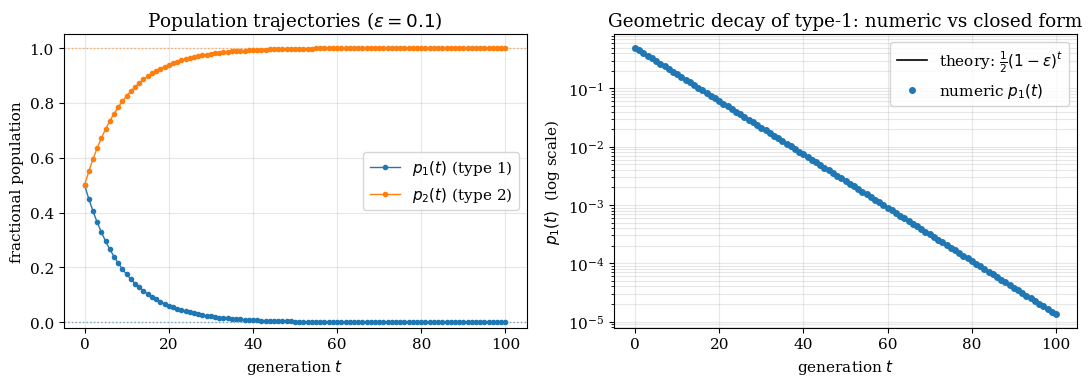

In [3]:
# ===== Part 1f — plot (linear + log) =====
import matplotlib.pyplot as plt
from pathlib import Path

# Match the report's serif typesetting.
plt.rcParams.update({"font.family": "serif", "font.size": 11})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Panel A: linear-scale trajectories ---
# Dotted horizontal lines mark the asymptotic values, making the limit
# in 1e visible at a glance.
ax = axes[0]
ax.plot(t, P_num[:, 0], "o-", color="tab:blue",   ms=3, lw=1,
        label=r"$p_1(t)$ (type 1)")
ax.plot(t, P_num[:, 1], "o-", color="tab:orange", ms=3, lw=1,
        label=r"$p_2(t)$ (type 2)")
ax.axhline(0, color="tab:blue",   ls=":", lw=1, alpha=0.6)
ax.axhline(1, color="tab:orange", ls=":", lw=1, alpha=0.6)
ax.set_xlabel(r"generation $t$")
ax.set_ylabel("fractional population")
ax.set_title(rf"Population trajectories ($\epsilon = {eps}$)")
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="center right")
ax.grid(alpha=0.3)

# --- Panel B: log-scale; numeric vs closed form ---
# A straight line on semilog-y proves the decay is geometric with rate
# (1 - eps); numeric dots sitting on the line validate the closed form.
theory_p1 = 0.5 * (1 - eps) ** t          # (1/2)(1-eps)^t

ax = axes[1]
ax.semilogy(t, theory_p1,   "-",  color="black",    lw=1.2,
            label=r"theory: $\frac{1}{2}(1-\epsilon)^t$")
ax.semilogy(t, P_num[:, 0], "o",  color="tab:blue", ms=4,
            label=r"numeric $p_1(t)$")
ax.set_xlabel(r"generation $t$")
ax.set_ylabel(r"$p_1(t)$  (log scale)")
ax.set_title("Geometric decay of type-1: numeric vs closed form")
ax.legend()
ax.grid(which="both", alpha=0.3)

fig.tight_layout()

# Save under data/output/ (repo convention). Walk up to the repo root so
# the path is correct regardless of the kernel's working directory.
root = Path.cwd().resolve()
while not (root / "data").is_dir() and root != root.parent:
    root = root.parent
out_dir = root / "data" / "output"
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "task1f_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 1h — Numerical validation of part (g): time-varying $\epsilon(t)$

The conversion rate now decays, $\epsilon(t) = \epsilon_0\,e^{-t/t_0}$, so the matrix $\mathbb{M}(t)$ changes every generation. The eigenvectors stay $\epsilon$-independent (same $\vec{\nu}_1, \vec{\nu}_2$ as 1b); only $\lambda_2(t) = 1-\epsilon(t)$ varies, so the geometric factor $(1-\epsilon)^t$ from 1d becomes a **cumulative product** $\Pi(t) = \prod_{s=0}^{t-1}\bigl(1-\epsilon(s)\bigr)$.

**Strategy.** Same two-track check as 1f — direct simulation with a per-step matrix $\mathbb{M}(t)$ vs the closed form $\vec{P}(t) = c_1\vec{\nu}_1 + c_2\,\Pi(t)\,\vec{\nu}_2$ — then plot the $\epsilon(t)$ trajectories **on top of the constant-$\epsilon$ curves from 1f** for comparison. Headline result (1g): because $\sum_s \epsilon(s)$ is finite, $p_1$ no longer vanishes but **freezes** at a positive residue $\tfrac{1}{2}\Pi(\infty) \approx \tfrac{1}{2}e^{-\epsilon_0 t_0}$.


In [4]:
# ===========================================================
# Part 1h — numerical validation of part (g): time-varying eps(t)
# ===========================================================
'''Purpose. Validate the part-(g) generalisation to a decaying rate eps(t)=eps0*exp(-t/t0),
and its qualitative consequence: type-1 is NOT fully depleted but freezes at a positive
residue. This is the key correction over the notes, which had (1-eps(t))^t instead of the
cumulative product.

Why a product, not a power. With eps time-varying the update matrix M(t) changes every step,
but its eigenvectors v1, v2 are eps-independent (same as 1b) and only lambda2(t)=1-eps(t)
varies. Acting on P(0)=c1*v1+c2*v2, the v2 mode collects ONE factor (1-eps(s)) per step, so
the geometric power (1-eps)^t of 1d becomes the cumulative product Pi(t)=prod_{s<t}(1-eps(s)).

Method (mirrors 1f). Track A: iterate with a freshly built M(s) each step. Track B: the
closed form c1*v1 + c2*Pi(t)*v2, with Pi computed by np.cumprod (Pi(0)=1, the empty product).
Reuses t, c1, c2, v1, v2 from the 1f cell.

Validation & outputs. max|A - B| < 1e-10 (asserted). Because sum_s eps(s) < infinity, Pi(inf)
is strictly positive, so p1 plateaus at c2*Pi(inf); we print this residue alongside the
small-eps / large-t0 estimate (1/2)e^(-eps0*t0) for a sanity check. Defines P_num_g, Pi,
plateau_p1 for the 1h plot cell.'''

eps0  = 0.5                               # initial conversion rate
t0    = 10.0                              # decay timescale of eps(t)
eps_t = eps0 * np.exp(-t / t0)            # eps(s) for s = 0..T  (t from 1f cell)

# --- Stage 1: direct simulation with a time-varying matrix ---
P_num_g = np.zeros((T + 1, 2))
P_num_g[0] = p0
for s in range(T):
    e = eps_t[s]
    M_s = np.array([[1 - e, 0.0],
                    [e,     1.0]])
    P_num_g[s + 1] = M_s @ P_num_g[s]

# --- Stage 2: closed form via the cumulative product Pi(t) ---
# Pi(0) = 1 (empty product); Pi(t) = prod_{s=0}^{t-1} (1 - eps(s)).
Pi = np.concatenate(([1.0], np.cumprod(1 - eps_t[:-1])))
P_closed_g = c1 * v1 + c2 * Pi[:, None] * v2   # reuse c1=1, c2=0.5, v1, v2 from 1f

# --- Stage 3: validation ---
max_err_g = np.max(np.abs(P_num_g - P_closed_g))
print(f"max |numeric - closed form| (1h) = {max_err_g:.2e}")
assert max_err_g < 1e-10, "1g closed form disagrees with simulation -- check the product"

# --- Asymptotic check (validates 1g): a frozen, non-zero residue ---
plateau_p1     = 0.5 * Pi[-1]             # actual residue p1(inf) = c2 * Pi(inf)
plateau_approx = 0.5 * np.exp(-eps0 * t0) # guide's small-eps / large-t0 estimate
print(f"P(T={T}) = {P_num_g[-1]}   (p1 freezes above 0, unlike 1f)")
print(f"residue p1(inf) = {plateau_p1:.6f}   "
      f"(approx (1/2)e^(-eps0*t0) = {plateau_approx:.6f})")

max |numeric - closed form| (1h) = 2.22e-16
P(T=100) = [0.00103826 0.99896174]   (p1 freezes above 0, unlike 1f)
residue p1(inf) = 0.001038   (approx (1/2)e^(-eps0*t0) = 0.003369)


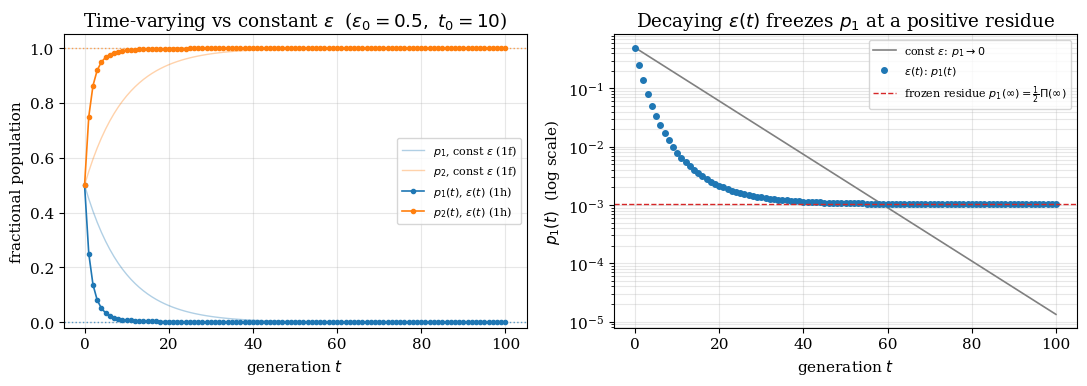

In [5]:
# ===== Part 1h — plot: time-varying eps(t) vs constant eps (1f) =====
import matplotlib.pyplot as plt
from pathlib import Path

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4))

# --- Panel A: linear scale, both scenarios overlaid ---
# Faded = constant eps (1f, for reference); solid = time-varying eps(t) (1h).
ax = axes2[0]
ax.plot(t, P_num[:, 0],   "-",  color="tab:blue",   lw=1, alpha=0.35,
        label=r"$p_1$, const $\epsilon$ (1f)")
ax.plot(t, P_num[:, 1],   "-",  color="tab:orange", lw=1, alpha=0.35,
        label=r"$p_2$, const $\epsilon$ (1f)")
ax.plot(t, P_num_g[:, 0], "o-", color="tab:blue",   ms=3, lw=1.2,
        label=r"$p_1(t)$, $\epsilon(t)$ (1h)")
ax.plot(t, P_num_g[:, 1], "o-", color="tab:orange", ms=3, lw=1.2,
        label=r"$p_2(t)$, $\epsilon(t)$ (1h)")
ax.axhline(plateau_p1,     color="tab:blue",   ls=":", lw=1, alpha=0.7)
ax.axhline(1 - plateau_p1, color="tab:orange", ls=":", lw=1, alpha=0.7)
ax.set_xlabel(r"generation $t$")
ax.set_ylabel("fractional population")
ax.set_title(rf"Time-varying vs constant $\epsilon$  ($\epsilon_0={eps0},\ t_0={t0:g}$)")
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="center right", fontsize=8)
ax.grid(alpha=0.3)

# --- Panel B: log scale -- the headline contrast ---
# Constant eps: p1 -> 0 (straight line on semilog-y). Time-varying eps(t):
# p1 *plateaus* at the frozen residue once eps(t) effectively switches off.
ax = axes2[1]
ax.semilogy(t, P_num[:, 0],   "-",  color="gray",     lw=1.2,
            label=r"const $\epsilon$: $p_1 \to 0$")
ax.semilogy(t, P_num_g[:, 0], "o",  color="tab:blue", ms=4,
            label=r"$\epsilon(t)$: $p_1(t)$")
ax.axhline(plateau_p1, color="tab:red", ls="--", lw=1,
           label=r"frozen residue $p_1(\infty)=\frac{1}{2}\Pi(\infty)$")
ax.set_xlabel(r"generation $t$")
ax.set_ylabel(r"$p_1(t)$  (log scale)")
ax.set_title(r"Decaying $\epsilon(t)$ freezes $p_1$ at a positive residue")
ax.legend(fontsize=8)
ax.grid(which="both", alpha=0.3)

fig2.tight_layout()

# Save under data/output/ (same repo-root resolution as the 1f cell).
root = Path.cwd().resolve()
while not (root / "data").is_dir() and root != root.parent:
    root = root.parent
out_dir = root / "data" / "output"
out_dir.mkdir(parents=True, exist_ok=True)
fig2.savefig(out_dir / "task1h_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
